<a href="https://colab.research.google.com/github/weloo11/mnist-image-classifier/blob/main/linearSVM(HOG)v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Image data shape: (70000, 28, 28)
Label shape: (70000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


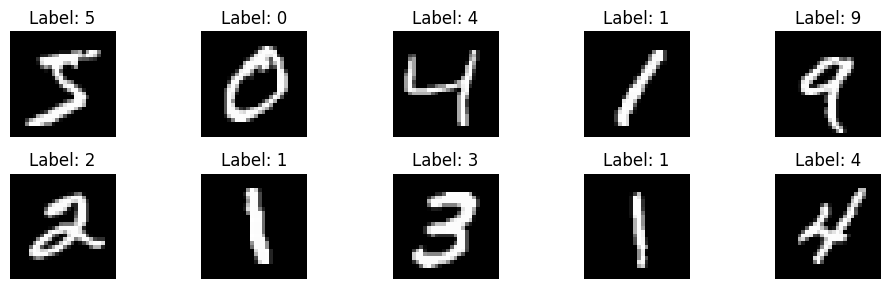

Target digit: 5
Positive samples: 6313
Negative samples: 63687
Positive ratio: 0.09018571428571429
Negative ratio: 0.9098142857142857
Min pixel value: 0.0
Max pixel value: 1.0
Train shape: (48999, 28, 28) (48999,)
Validation shape: (10499, 28, 28) (10499,)
Test shape: (10502, 28, 28) (10502,)
Training set:
  Positives = 4419 (0.0902)
  Negatives = 44580 (0.9098)
Validation set:
  Positives = 946 (0.0901)
  Negatives = 9553 (0.9099)
Test set:
  Positives = 948 (0.0903)
  Negatives = 9554 (0.9097)
HOG feature length for one image: 1296
HOG training shape: (48999, 1296)
HOG validation shape: (10499, 1296)
HOG test shape: (10502, 1296)
Scaled HOG training shape: (48999, 1296)
Scaled HOG validation shape: (10499, 1296)
Scaled HOG test shape: (10502, 1296)
Epoch 1/60, Loss: 0.156801, Val F1: 0.714177
Epoch 2/60, Loss: 0.083233, Val F1: 0.852820
Epoch 3/60, Loss: 0.053572, Val F1: 0.899322
Epoch 4/60, Loss: 0.042773, Val F1: 0.910345
Epoch 5/60, Loss: 0.043687, Val F1: 0.909181
Epoch 6/60, Lo

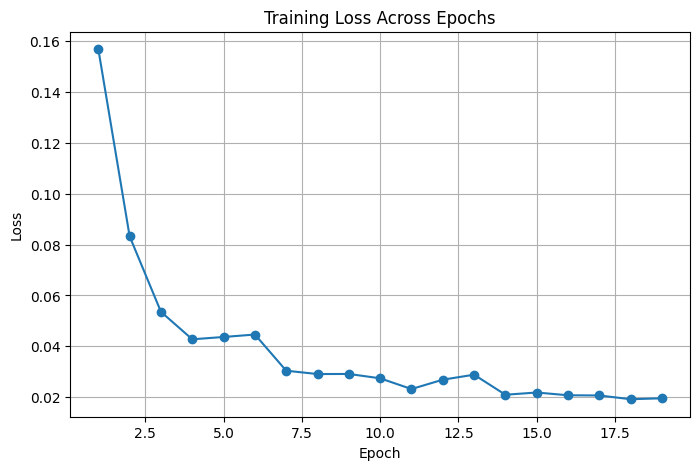


===== THRESHOLD TUNING ON VALIDATION =====
Threshold -0.5: F1 = 0.901014
Threshold -0.2: F1 = 0.929000
Threshold 0.0: F1 = 0.943032
Threshold 0.2: F1 = 0.953165
Threshold 0.5: F1 = 0.961134
Threshold 1.0: F1 = 0.960732
Best threshold: 0.5
Best validation F1 from threshold tuning: 0.9611344537815125

===== VALIDATION RESULTS =====
Accuracy : 0.9929517096866368
Precision: 0.9551148225469729
Recall   : 0.96723044397463
F1-score : 0.9611344537815125
Confusion Matrix:
 [[9510   43]
 [  31  915]]

Classification Report
---------------------
Accuracy : 0.992952
Precision: 0.955115
Recall   : 0.967230
F1-score : 0.961134

===== TEST RESULTS =====
Accuracy : 0.9907636640639879
Precision: 0.9355168884339816
Recall   : 0.9641350210970464
F1-score : 0.9496103896103896
Confusion Matrix:
 [[9491   63]
 [  34  914]]

Classification Report
---------------------
Accuracy : 0.990764
Precision: 0.935517
Recall   : 0.964135
F1-score : 0.949610
Preprocessed HOG features and labels saved as .npy files.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from skimage.feature import hog

# =========================================
# 1) Choose target digit
# =========================================
TARGET_DIGIT = 5

# =========================================
# 2) Manual stratified train/val/test split
# =========================================
def stratified_train_val_test_split(X, y, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15, random_state=42):
    np.random.seed(random_state)

    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8, "Ratios must sum to 1"

    class_0_idx = np.where(y == 0)[0]
    class_1_idx = np.where(y == 1)[0]

    np.random.shuffle(class_0_idx)
    np.random.shuffle(class_1_idx)

    def split_indices(indices):
        n = len(indices)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_idx = indices[:n_train]
        val_idx = indices[n_train:n_train + n_val]
        test_idx = indices[n_train + n_val:]

        return train_idx, val_idx, test_idx

    c0_train, c0_val, c0_test = split_indices(class_0_idx)
    c1_train, c1_val, c1_test = split_indices(class_1_idx)

    train_idx = np.concatenate([c0_train, c1_train])
    val_idx   = np.concatenate([c0_val, c1_val])
    test_idx  = np.concatenate([c0_test, c1_test])

    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)
    np.random.shuffle(test_idx)

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val     = X[val_idx], y[val_idx]
    X_test, y_test   = X[test_idx], y[test_idx]

    return X_train, X_val, X_test, y_train, y_val, y_test

# =========================================
# 3) Manual StandardScaler
# =========================================
class ManualStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

# =========================================
# 4) Manual metrics
# =========================================
def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return np.array([[tn, fp],
                     [fn, tp]])

def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_score_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    if tp + fp == 0:
        return 0.0
    return tp / (tp + fp)

def recall_score_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    if tp + fn == 0:
        return 0.0
    return tp / (tp + fn)

def f1_score_manual(y_true, y_pred):
    precision = precision_score_manual(y_true, y_pred)
    recall = recall_score_manual(y_true, y_pred)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def print_classification_report_manual(y_true, y_pred):
    accuracy = accuracy_score_manual(y_true, y_pred)
    precision = precision_score_manual(y_true, y_pred)
    recall = recall_score_manual(y_true, y_pred)
    f1 = f1_score_manual(y_true, y_pred)

    print("\nClassification Report")
    print("---------------------")
    print(f"Accuracy : {accuracy:.6f}")
    print(f"Precision: {precision:.6f}")
    print(f"Recall   : {recall:.6f}")
    print(f"F1-score : {f1:.6f}")

# =========================================
# 5) HOG extraction
# =========================================
def extract_hog_features(images):
    hog_features = []
    for img in images:
        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )
        hog_features.append(features)
    return np.array(hog_features)

# =========================================
# 6) Linear SVM from scratch
# =========================================
class LinearSVMFromScratch:
    def __init__(
        self,
        learning_rate=0.01,
        lambda_param=0.0005,
        n_epochs=60,
        batch_size=512,
        lr_decay=0.95,
        patience=8
    ):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lr_decay = lr_decay
        self.patience = patience

        self.w = None
        self.b = 0.0

        self.train_losses = []
        self.best_w = None
        self.best_b = None
        self.best_f1 = -1.0

    def _compute_class_weights(self, y):
        n_samples = len(y)
        n_pos = np.sum(y == 1)
        n_neg = np.sum(y == -1)

        weight_pos = n_samples / (2 * n_pos)
        weight_neg = n_samples / (2 * n_neg)
        return weight_pos, weight_neg

    def _hinge_loss(self, X, y, weight_pos, weight_neg):
        scores = X @ self.w + self.b
        margins = y * scores
        sample_weights = np.where(y == 1, weight_pos, weight_neg)
        hinge = np.maximum(0, 1 - margins)
        loss = self.lambda_param * np.dot(self.w, self.w) + np.mean(sample_weights * hinge)
        return loss

    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features, dtype=np.float64)
        self.b = 0.0

        weight_pos, weight_neg = self._compute_class_weights(y)
        current_lr = self.learning_rate
        no_improve_count = 0

        for epoch in range(self.n_epochs):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                if len(X_batch) == 0:
                    continue

                scores = X_batch @ self.w + self.b
                margins = y_batch * scores

                sample_weights = np.where(y_batch == 1, weight_pos, weight_neg)
                active = margins < 1

                if np.any(active):
                    X_active = X_batch[active]
                    y_active = y_batch[active]
                    w_active = sample_weights[active]

                    grad_w_hinge = -np.mean(
                        (w_active * y_active)[:, np.newaxis] * X_active,
                        axis=0
                    )
                    grad_b_hinge = -np.mean(w_active * y_active)
                else:
                    grad_w_hinge = np.zeros_like(self.w)
                    grad_b_hinge = 0.0

                grad_w = 2 * self.lambda_param * self.w + grad_w_hinge
                grad_b = grad_b_hinge

                self.w -= current_lr * grad_w
                self.b -= current_lr * grad_b

            train_loss = self._hinge_loss(X, y, weight_pos, weight_neg)
            self.train_losses.append(train_loss)

            msg = f"Epoch {epoch + 1}/{self.n_epochs}, Loss: {train_loss:.6f}"

            if X_val is not None and y_val is not None:
                y_val_pred = self.predict(X_val)
                y_val_binary = np.where(y_val == 1, 1, 0)
                y_val_pred_binary = np.where(y_val_pred == 1, 1, 0)
                val_f1 = f1_score_manual(y_val_binary, y_val_pred_binary)

                msg += f", Val F1: {val_f1:.6f}"

                if val_f1 > self.best_f1:
                    self.best_f1 = val_f1
                    self.best_w = self.w.copy()
                    self.best_b = self.b
                    no_improve_count = 0
                else:
                    no_improve_count += 1

                if no_improve_count >= self.patience:
                    print(msg)
                    print("Early stopping triggered.")
                    break

            print(msg)
            current_lr *= self.lr_decay

        if self.best_w is not None:
            self.w = self.best_w
            self.b = self.best_b

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1, -1)

    def predict_with_threshold(self, X, threshold=0.0):
        scores = self.decision_function(X)
        return np.where(scores >= threshold, 1, -1)

# =========================================
# 7) Load MNIST
# =========================================
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# =========================================
# 8) Combine full dataset
# =========================================
X = np.concatenate([X_train_full, X_test_full], axis=0)
y = np.concatenate([y_train_full, y_test_full], axis=0)

print("Image data shape:", X.shape)
print("Label shape:", y.shape)
print("Unique labels:", np.unique(y))

# =========================================
# 9) Show sample images
# =========================================
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i], cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# =========================================
# 10) Convert labels to binary
# =========================================
y_binary = (y == TARGET_DIGIT).astype(int)

num_positive = np.sum(y_binary == 1)
num_negative = np.sum(y_binary == 0)

print("Target digit:", TARGET_DIGIT)
print("Positive samples:", num_positive)
print("Negative samples:", num_negative)
print("Positive ratio:", num_positive / len(y_binary))
print("Negative ratio:", num_negative / len(y_binary))

# =========================================
# 11) Normalize images to [0,1]
# =========================================
X = X.astype("float32") / 255.0

print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

# =========================================
# 12) Manual stratified split
# =========================================
X_train, X_val, X_test, y_train, y_val, y_test = stratified_train_val_test_split(
    X, y_binary,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

def print_class_distribution(name, labels):
    positives = np.sum(labels == 1)
    negatives = np.sum(labels == 0)
    total = len(labels)
    print(f"{name}:")
    print(f"  Positives = {positives} ({positives / total:.4f})")
    print(f"  Negatives = {negatives} ({negatives / total:.4f})")

print_class_distribution("Training set", y_train)
print_class_distribution("Validation set", y_val)
print_class_distribution("Test set", y_test)

# =========================================
# 13) HOG feature extraction
# =========================================
sample_hog = hog(
    X_train[0],
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm="L2-Hys"
)
print("HOG feature length for one image:", len(sample_hog))

X_train_hog = extract_hog_features(X_train)
X_val_hog   = extract_hog_features(X_val)
X_test_hog  = extract_hog_features(X_test)

print("HOG training shape:", X_train_hog.shape)
print("HOG validation shape:", X_val_hog.shape)
print("HOG test shape:", X_test_hog.shape)

# =========================================
# 14) Manual standardization
# =========================================
hog_scaler = ManualStandardScaler()

X_train_hog_scaled = hog_scaler.fit_transform(X_train_hog)
X_val_hog_scaled   = hog_scaler.transform(X_val_hog)
X_test_hog_scaled  = hog_scaler.transform(X_test_hog)

print("Scaled HOG training shape:", X_train_hog_scaled.shape)
print("Scaled HOG validation shape:", X_val_hog_scaled.shape)
print("Scaled HOG test shape:", X_test_hog_scaled.shape)

# =========================================
# 15) Convert labels to {-1, +1}
# =========================================
y_train_svm = np.where(y_train == 1, 1, -1)
y_val_svm   = np.where(y_val == 1, 1, -1)
y_test_svm  = np.where(y_test == 1, 1, -1)

# =========================================
# 16) Train improved SVM
# =========================================
svm_model = LinearSVMFromScratch(
    learning_rate=0.01,
    lambda_param=0.0005,
    n_epochs=60,
    batch_size=512,
    lr_decay=0.95,
    patience=8
)

svm_model.fit(
    X_train_hog_scaled,
    y_train_svm,
    X_val=X_val_hog_scaled,
    y_val=y_val_svm
)

# =========================================
# 17) Plot training loss
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(svm_model.train_losses) + 1), svm_model.train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Across Epochs")
plt.grid(True)
plt.show()

# =========================================
# 18) Threshold tuning on validation set
# =========================================
thresholds = [-0.5, -0.2, 0.0, 0.2, 0.5, 1.0]

best_threshold = 0.0
best_threshold_f1 = -1.0

print("\n===== THRESHOLD TUNING ON VALIDATION =====")
for t in thresholds:
    preds = svm_model.predict_with_threshold(X_val_hog_scaled, threshold=t)
    preds_binary = np.where(preds == 1, 1, 0)
    score = f1_score_manual(y_val, preds_binary)
    print(f"Threshold {t}: F1 = {score:.6f}")

    if score > best_threshold_f1:
        best_threshold_f1 = score
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best validation F1 from threshold tuning:", best_threshold_f1)

# =========================================
# 19) Validation evaluation
# =========================================
y_val_pred_svm = svm_model.predict_with_threshold(X_val_hog_scaled, threshold=best_threshold)
y_val_pred = np.where(y_val_pred_svm == 1, 1, 0)

print("\n===== VALIDATION RESULTS =====")
print("Accuracy :", accuracy_score_manual(y_val, y_val_pred))
print("Precision:", precision_score_manual(y_val, y_val_pred))
print("Recall   :", recall_score_manual(y_val, y_val_pred))
print("F1-score :", f1_score_manual(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix_manual(y_val, y_val_pred))
print_classification_report_manual(y_val, y_val_pred)

# =========================================
# 20) Test evaluation
# =========================================
y_test_pred_svm = svm_model.predict_with_threshold(X_test_hog_scaled, threshold=best_threshold)
y_test_pred = np.where(y_test_pred_svm == 1, 1, 0)

print("\n===== TEST RESULTS =====")
print("Accuracy :", accuracy_score_manual(y_test, y_test_pred))
print("Precision:", precision_score_manual(y_test, y_test_pred))
print("Recall   :", recall_score_manual(y_test, y_test_pred))
print("F1-score :", f1_score_manual(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix_manual(y_test, y_test_pred))
print_classification_report_manual(y_test, y_test_pred)

# =========================================
# 21) Save arrays if needed
# =========================================
np.save("X_train_hog.npy", X_train_hog_scaled)
np.save("X_val_hog.npy", X_val_hog_scaled)
np.save("X_test_hog.npy", X_test_hog_scaled)

np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)

print("Preprocessed HOG features and labels saved as .npy files.")